# Эксперимент 3 - RoBERTa + Soft-Labels + Focal Loss

| | |
|---|---|
| **Модель** | `roberta-base` |
| **Разметка** | soft-labels (вещественные значения [0.0, 1.0]) + нормализация по максимуму |
| **Лосс** | Focal Loss |



**Focal Loss** автоматически снижает вес легких примеров и фокусируется на сложных.  
Хорошо работает при дисбалансе классов (у нас редкие классы вроде `grief`, `relief` с малым числом примеров).

## Импорты и версии библиотек

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from IPython.display import display

In [2]:
packages = ['NumPy', 'Pandas', 'Polars', 'Matplotlib', 'Seaborn', 'Torch', 'Transformers']
package_objects = [np, pd, pl, mpl, sns, torch, __import__('transformers')]
versions = [obj.__version__ for obj in package_objects]

columns_order = ['№', 'Библиотека', 'Версия']
df_pkgs = (
    pl.DataFrame({columns_order[1]: packages, columns_order[2]: versions})
    .with_columns(pl.arange(1, pl.lit(len(packages)) + 1).alias(columns_order[0]))
    .select(columns_order)
)
display(df_pkgs)

№,Библиотека,Версия
i64,str,str
1,"""NumPy""","""2.0.2"""
2,"""Pandas""","""2.2.2"""
3,"""Polars""","""1.35.2"""
4,"""Matplotlib""","""3.10.0"""
5,"""Seaborn""","""0.13.2"""
6,"""Torch""","""2.10.0+cu128"""
7,"""Transformers""","""5.0.0"""


In [3]:
CONFIG = {
    'model_name': 'roberta-base',
    'max_length': 64,
    'batch_size': 32,
    'num_epochs': 5,
    'learning_rate': 2e-5,
    'threshold': 0.5,
    'num_labels': 28,
    'focal_gamma': 2.0,
    'focal_alpha': 0.25,
    'data_dir': '.',
    'results_dir': 'results',
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
EMOTIONS = [
    'admiration', 'amusement', 'approval', 'caring', 'desire',
    'excitement', 'gratitude', 'joy', 'love', 'optimism',
    'pride', 'relief', 'anger', 'annoyance', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'fear', 'grief',
    'nervousness', 'remorse', 'sadness', 'confusion', 'curiosity',
    'realization', 'surprise', 'neutral',
]
NUM_EMOTIONS = len(EMOTIONS)
print(f'Эмоций: {NUM_EMOTIONS}')

Эмоций: 28


## Загрузка данных


In [30]:
def load_data():
    soft_path = os.path.join(CONFIG['data_dir'], 'train_soft.csv')
    if not os.path.exists(soft_path):
        raise FileNotFoundError('train_soft.csv не найден')

    train_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'train_soft.csv'))
    val_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'val_soft.csv'))
    test_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'test_soft.csv'))

    oh_path = os.path.join(CONFIG['data_dir'], 'train.csv')
    if os.path.exists(oh_path):
        train_oh = pd.read_csv(oh_path)
        val_oh = pd.read_csv(os.path.join(CONFIG['data_dir'], 'val.csv'))
        test_oh = pd.read_csv(os.path.join(CONFIG['data_dir'], 'test.csv'))
    else:
        def binarize(df):
            result = df[['id', 'text']].copy()
            for e in EMOTIONS:
                result[e] = (df[e] >= 0.5).astype(int)
            return result
        train_oh = binarize(train_soft)
        val_oh = binarize(val_soft)
        test_oh = binarize(test_soft)

    def align(soft, oh):
        common_ids = set(soft['id']) & set(oh['id'])
        soft = soft[soft['id'].isin(common_ids)].sort_values('id').reset_index(drop=True)
        oh = oh[oh['id'].isin(common_ids)].sort_values('id').reset_index(drop=True)
        print(f'  общих id: {len(common_ids)}  soft: {len(soft)}  onehot: {len(oh)}')
        return soft, oh

    train_soft, train_oh = align(train_soft, train_oh)
    val_soft, val_oh = align(val_soft, val_oh)
    test_soft, test_oh = align(test_soft, test_oh)

    return train_soft, val_soft, test_soft, train_oh, val_oh, test_oh

train_soft, val_soft, test_soft, train_oh, val_oh, test_oh = load_data()

print(f'train_soft: {train_soft.shape}')
print(f'val_soft:   {val_soft.shape}')
print(f'test_soft:  {test_soft.shape}')

  общих id: 43410  soft: 43410  onehot: 43410
  общих id: 5426  soft: 5426  onehot: 5426
  общих id: 5427  soft: 5427  onehot: 5427
train_soft: (43410, 30)
val_soft:   (5426, 30)
test_soft:  (5427, 30)


In [31]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Токенизатор: {CONFIG["model_name"]}')

max_len_path = os.path.join(CONFIG['data_dir'], 'max_length.txt')
if os.path.exists(max_len_path):
    with open(max_len_path) as f:
        CONFIG['max_length'] = int(f.read().strip())
    print(f'max_length: {CONFIG["max_length"]}')
else:
    print(f'max_length из конфига: {CONFIG["max_length"]}')

Токенизатор: roberta-base
max_length из конфига: 64


## Dataset и DataLoader

Используем нормализацию по максимуму как в exp2


In [32]:
class SoftEmotionDatasetNorm(Dataset):
    # Soft-labels нормализованные по максимуму строки
    # Возвращает soft_labels для лосса и onehot_labels для метрик
    def __init__(self, soft_df, onehot_df, tokenizer, max_length, emotions):
        self.texts = soft_df['text'].tolist()
        self.soft_labels = soft_df[emotions].values.astype(np.float32)
        self.onehot_labels = onehot_df[emotions].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        soft = self.soft_labels[idx].copy()
        max_val = soft.max()
        if max_val > 0:
            soft = soft / max_val
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'soft_labels': torch.tensor(soft, dtype=torch.float32),
            'onehot_labels': torch.tensor(self.onehot_labels[idx], dtype=torch.float32),
        }

In [33]:
train_dataset = SoftEmotionDatasetNorm(train_soft, train_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
val_dataset = SoftEmotionDatasetNorm(val_soft, val_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
test_dataset = SoftEmotionDatasetNorm(test_soft, test_oh, tokenizer, CONFIG['max_length'], EMOTIONS)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'train batches: {len(train_loader)}')
print(f'val batches:   {len(val_loader)}')
print(f'test batches:  {len(test_loader)}')

sample = train_dataset[0]['soft_labels'].numpy()
nonzero = {EMOTIONS[i]: round(float(sample[i]), 3) for i in range(28) if sample[i] > 0}
print(f'\nПример нормализованного вектора: {nonzero}')

train batches: 1357
val batches:   170
test batches:  170

Пример нормализованного вектора: {'approval': 1.0}


## Модель и Focal Loss

RoBERTa -> [CLS] -> Dropout -> Linear(768, 28)


In [34]:
class RoBERTaForEmotions(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [35]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)

        focal_weight = (1 - pt) ** self.gamma

        loss = self.alpha * focal_weight * bce
        return loss.mean()

In [36]:
model = RoBERTaForEmotions(CONFIG['model_name'], CONFIG['num_labels'])
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров:  {total_params:,}')
print(f'Обучаемых:         {trainable_params:,}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Всего параметров:  124,667,164
Обучаемых:         124,667,164


In [37]:
criterion = FocalLoss(gamma=CONFIG['focal_gamma'], alpha=CONFIG['focal_alpha'])

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
)

print(f'Лосс: FocalLoss(gamma={CONFIG["focal_gamma"]}, alpha={CONFIG["focal_alpha"]})')
print(f'Оптимизатор: AdamW, lr={CONFIG["learning_rate"]}')
print(f'Шедулер: CosineAnnealingLR, T_max={CONFIG["num_epochs"]}')

Лосс: FocalLoss(gamma=2.0, alpha=0.25)
Оптимизатор: AdamW, lr=2e-05
Шедулер: CosineAnnealingLR, T_max=5


## Обучение

In [38]:
def compute_metrics(labels, preds, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)
    return {
        'micro_f1': round(f1_score(labels, binary_preds, average='micro', zero_division=0), 4),
        'macro_f1': round(f1_score(labels, binary_preds, average='macro', zero_division=0), 4),
        'hamming': round(hamming_loss(labels, binary_preds), 4),
        'subset_acc': round(accuracy_score(labels, binary_preds), 4),
    }

In [39]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        soft_labels = batch['soft_labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, soft_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    all_onehot = []
    all_preds = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='eval', leave=False)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            soft_labels = batch['soft_labels'].to(device)
            onehot_labels = batch['onehot_labels']

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, soft_labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_onehot.append(onehot_labels.numpy())

    all_preds = np.vstack(all_preds)
    all_onehot = np.vstack(all_onehot)
    metrics = compute_metrics(all_onehot, all_preds, threshold)
    metrics['loss'] = round(total_loss / len(loader), 4)
    return metrics, all_onehot, all_preds

In [40]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_micro_f1': [],
    'val_macro_f1': [],
}

best_macro_f1 = 0
best_model_path = os.path.join(CONFIG['results_dir'], 'soft_focal_best.pt')
patience = 2
no_improve = 0

print('Начало обучения')
print(f'Эпох: {CONFIG["num_epochs"]}  |  Батч: {CONFIG["batch_size"]}  |  lr: {CONFIG["learning_rate"]}')
print(f'Focal: gamma={CONFIG["focal_gamma"]}, alpha={CONFIG["focal_alpha"]}')
print()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_micro_f1'].append(val_metrics['micro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])

    if val_metrics['macro_f1'] > best_macro_f1:
        best_macro_f1 = val_metrics['macro_f1']
        torch.save(model.state_dict(), best_model_path)
        flag = ' <- best'
        no_improve = 0
    else:
        flag = ''
        no_improve += 1

    print(
        f'Epoch {epoch}/{CONFIG["num_epochs"]} | '
        f'train_loss: {train_loss:.4f} | '
        f'val_loss: {val_metrics["loss"]:.4f} | '
        f'micro_f1: {val_metrics["micro_f1"]:.4f} | '
        f'macro_f1: {val_metrics["macro_f1"]:.4f}'
        f'{flag}'
    )

    if no_improve >= patience:
        print(f'Ранняя остановка на эпохе {epoch}')
        break

print()
print(f'Лучший Macro-F1 на val: {best_macro_f1:.4f}')

Начало обучения
Эпох: 5  |  Батч: 32  |  lr: 2e-05
Focal: gamma=2.0, alpha=0.25



train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 1/5 | train_loss: 0.0088 | val_loss: 0.0076 | micro_f1: 0.2913 | macro_f1: 0.1014 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

...

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 4/5 | train_loss: 0.0062 | val_loss: 0.0075 | micro_f1: 0.3116 | macro_f1: 0.1052 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 5/5 | train_loss: 0.0059 | val_loss: 0.0075 | micro_f1: 0.3031 | macro_f1: 0.1053 <- best

Лучший Macro-F1 на val: 0.1053


## Оценка на тесте

In [41]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Загружена лучшая модель: {best_model_path}')

test_metrics, test_labels, test_preds = eval_epoch(model, test_loader, criterion, DEVICE)

print()
print('Результаты на test (threshold=0.5)')
print()
print(f'Micro-F1: {test_metrics["micro_f1"]}')
print(f'Macro-F1: {test_metrics["macro_f1"]}')
print(f'Hamming Loss: {test_metrics["hamming"]}')
print(f'Subset Acc: {test_metrics["subset_acc"]}')
print()

Загружена лучшая модель: results/soft_focal_best.pt


eval:   0%|          | 0/170 [00:00<?, ?it/s]


Результаты на test (threshold=0.5)

Micro-F1: 0.3005
Macro-F1: 0.107
Hamming Loss: 0.0598
Subset Acc: 0.2381



In [ ]:
binary_preds = (test_preds >= CONFIG['threshold']).astype(int)

per_class_f1 = f1_score(test_labels, binary_preds, average=None, zero_division=0)
df_per_class = pd.DataFrame({
    'emotion': EMOTIONS,
    'f1': per_class_f1.round(4),
    'support': test_labels.sum(axis=0).astype(int),
}).sort_values('f1', ascending=False).reset_index(drop=True)

print('Per-class F1 на test:')
display(df_per_class)

df_per_class.to_csv(
    os.path.join(CONFIG['results_dir'], 'soft_focal_per_class_f1.csv'),
    index=False
)
print('Сохранено: results/soft_focal_per_class_f1.csv')

## Подбор порога бинаризации

In [43]:
_, val_labels, val_preds = eval_epoch(model, val_loader, criterion, DEVICE)

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results_thresh = []

for thresh in thresholds:
    binary = (val_preds >= thresh).astype(int)
    macro = f1_score(val_labels, binary, average='macro', zero_division=0)
    micro = f1_score(val_labels, binary, average='micro', zero_division=0)
    results_thresh.append({'threshold': thresh, 'macro_f1': round(macro, 4), 'micro_f1': round(micro, 4)})
    print(f'threshold={thresh:.2f}  macro_f1={macro:.4f}  micro_f1={micro:.4f}')

df_thresh = pd.DataFrame(results_thresh)
best_row = df_thresh.loc[df_thresh['macro_f1'].idxmax()]
best_threshold = best_row['threshold']
print(f'\nЛучший порог по Macro-F1: {best_threshold}  (macro_f1={best_row["macro_f1"]})')

eval:   0%|          | 0/170 [00:00<?, ?it/s]

threshold=0.05  macro_f1=0.0749  micro_f1=0.0869
threshold=0.10  macro_f1=0.0765  micro_f1=0.1168
threshold=0.15  macro_f1=0.0870  micro_f1=0.1547
threshold=0.20  macro_f1=0.0940  micro_f1=0.1898
threshold=0.25  macro_f1=0.0998  micro_f1=0.2217
threshold=0.30  macro_f1=0.1044  micro_f1=0.2490
threshold=0.35  macro_f1=0.1064  micro_f1=0.2708
threshold=0.40  macro_f1=0.1074  micro_f1=0.2882
threshold=0.45  macro_f1=0.1074  micro_f1=0.2987
threshold=0.50  macro_f1=0.1053  micro_f1=0.3031

Лучший порог по Macro-F1: 0.4  (macro_f1=0.1074)


In [ ]:
binary_test_best = (test_preds >= best_threshold).astype(int)
macro_test = f1_score(test_labels, binary_test_best, average='macro', zero_division=0)
micro_test = f1_score(test_labels, binary_test_best, average='micro', zero_division=0)
hamming_test = hamming_loss(test_labels, binary_test_best)
acc_test = accuracy_score(test_labels, binary_test_best)

print()
print('Результаты на test (threshold=0.5)')
print()
print(f'Micro-F1: {micro_test:.4f}')
print(f'Macro-F1: {macro_test:.4f}')
print(f'Hamming Loss: {hamming_test:.4f}')
print(f'Subset Acc: {acc_test:.4f}')

##Визуализация

In [ ]:
sns.set_theme(style='whitegrid', font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RoBERTa + Soft-Labels + Focal Loss - кривые обучения', fontsize=13, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', color='#5C6BC0', label='train loss')
ax.plot(epochs_range, history['val_loss'], 'o-', color='#EF5350', label='val loss')
ax.set_title('Loss', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal Loss')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax2 = axes[1]
ax2.plot(epochs_range, history['val_micro_f1'], 'o-', color='#42A5F5', label='Micro-F1')
ax2.plot(epochs_range, history['val_macro_f1'], 'o-', color='#66BB6A', label='Macro-F1')
ax2.set_title('F1 на val', fontsize=11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_focal_training_curves.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_focal_training_curves.png')

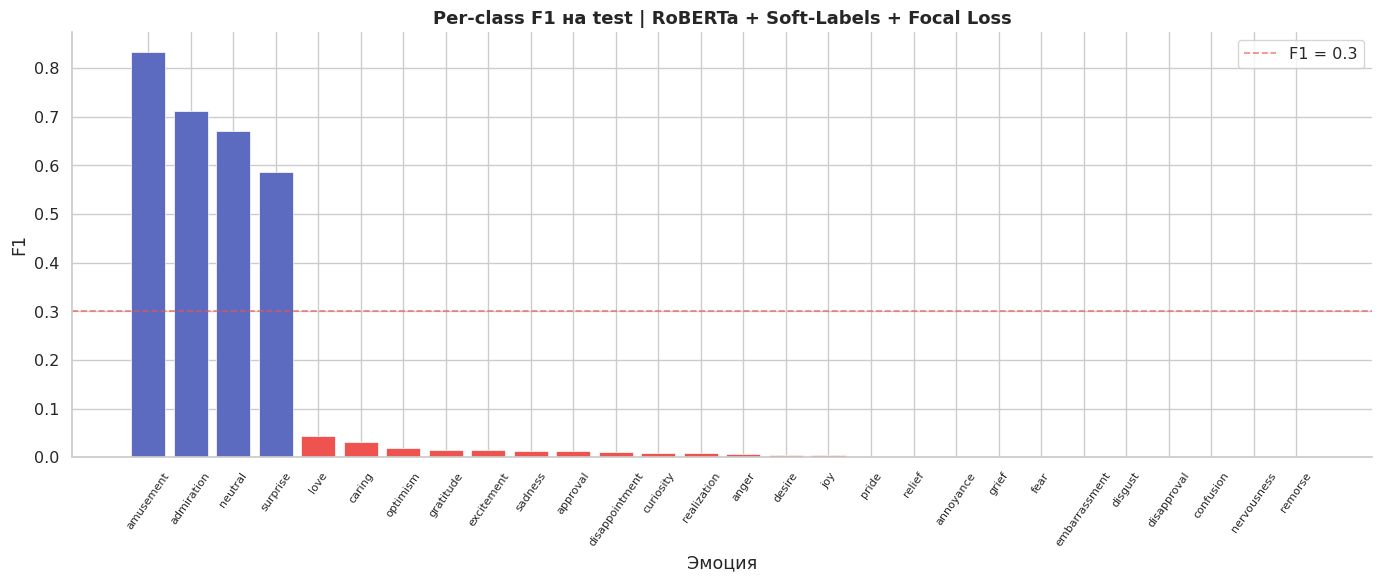

Сохранено: results/soft_focal_per_class_f1.png


In [46]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#EF5350' if f < 0.3 else '#5C6BC0' for f in df_per_class['f1']]
ax.bar(df_per_class['emotion'], df_per_class['f1'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.3, color='#EF5350', linestyle='--', linewidth=1.2, alpha=0.7, label='F1 = 0.3')
ax.set_title('Per-class F1 на test | RoBERTa + Soft-Labels + Focal Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Эмоция')
ax.set_ylabel('F1')
ax.tick_params(axis='x', rotation=55, labelsize=8)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_focal_per_class_f1.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_focal_per_class_f1.png')

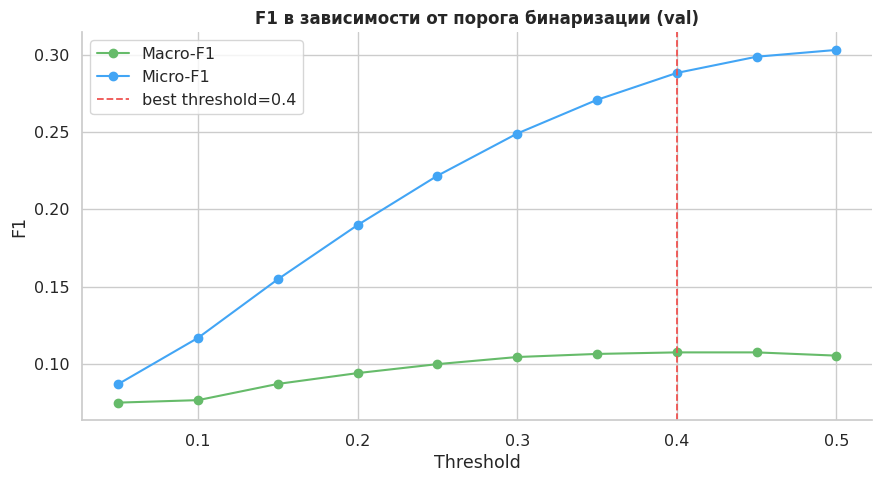

Сохранено: results/soft_focal_threshold_search.png


In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_thresh['threshold'], df_thresh['macro_f1'], 'o-', color='#66BB6A', label='Macro-F1')
ax.plot(df_thresh['threshold'], df_thresh['micro_f1'], 'o-', color='#42A5F5', label='Micro-F1')
ax.axvline(best_threshold, color='#EF5350', linestyle='--', linewidth=1.3,
           label=f'best threshold={best_threshold}')
ax.set_title('F1 в зависимости от порога бинаризации (val)', fontsize=12, fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_focal_threshold_search.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_focal_threshold_search.png')

In [48]:
exp1_class_path = os.path.join(CONFIG['results_dir'], 'onehot_bce_per_class_f1.csv')
if os.path.exists(exp1_class_path):
    df_exp1 = pd.read_csv(exp1_class_path)
    df_diff = df_per_class.merge(df_exp1[['emotion', 'f1']], on='emotion', suffixes=('_focal', '_onehot'))
    df_diff['delta'] = (df_diff['f1_focal'] - df_diff['f1_onehot']).round(4)
    df_diff = df_diff.sort_values('delta', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['#43A047' if d > 0 else '#EF5350' for d in df_diff['delta']]
    ax.bar(df_diff['emotion'], df_diff['delta'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='#333', linewidth=0.8)
    ax.set_title(
        'Изменение per-class F1: Exp3 (soft+Focal) - Exp1 (one-hot+BCE)\n'
        'Зеленый = Focal+soft улучшил  |  Красный = ухудшил',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Эмоция')
    ax.set_ylabel('delta F1')
    ax.tick_params(axis='x', rotation=55, labelsize=8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_focal_vs_onehot_delta.png'), dpi=150)
    plt.show()
    print('Сохранено: results/soft_focal_vs_onehot_delta.png')
else:
    print('onehot_bce_per_class_f1.csv не найден')

onehot_bce_per_class_f1.csv не найден


## Сохранение результатов

In [49]:
results = {
    'experiment': 'soft_focal',
    'model': CONFIG['model_name'],
    'label_type': 'soft-labels + norm',
    'loss': 'FocalLoss',
    'focal_gamma': CONFIG['focal_gamma'],
    'focal_alpha': CONFIG['focal_alpha'],
    'best_threshold': best_threshold,
    'config': CONFIG,
    'val_best_macro_f1': best_macro_f1,
    'test_metrics': test_metrics,
    'test_metrics_best_threshold': {
        'micro_f1': round(micro_test, 4),
        'macro_f1': round(macro_test, 4),
        'hamming': round(hamming_test, 4),
        'subset_acc': round(acc_test, 4),
    },
    'history': history,
}

results_path = os.path.join(CONFIG['results_dir'], 'soft_focal_metrics.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f'Сохранено: {results_path}')

Сохранено: results/soft_focal_metrics.json


Выводы: по сравнению с exp2 (soft-label + BCE loss) Macro-F1 вырос (было 0.036, стало около 0.1), но все еще хуже, чем при one-hot разметке (там 0.49). При этом выросла метрика Micro-F1 по сравнению с exp2 (при soft-label + BCE было 0.1, при one-hot + BCE 0.58)